# Предобучение визуального энкодера (классификация слов)

Обучаем MBConv CNN различать визуальные паттерны разных слов/токенов.
После обучения сохраняем веса CNN для загрузки в полную модель.

**Подход:**
1. Из каждого pkl берём окно кадров + соответствующий BPE-токен
2. Топ-N частых токенов → классы, остальные → отбрасываются
3. CNN обучается предсказывать токен по кадрам
4. Сохраняем веса CNN для fine-tuning

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import pickle
import numpy as np
import copy
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from datetime import datetime

from encoder_classifier import VisualEncoderClassifier, load_config

## Параметры

In [3]:
# ── Пути ──
DATA_PATH   = Path("D:/Datasets/Dataset_merged_bpe")
CONFIG_PATH = Path("../python_mbconv/configs/model_config_mbconv_micro_merged.json")
SAVE_PATH   = Path("pretrained_cnn.pt")  # куда сохранить веса CNN

# Сплиты (для предобучения используем все данные, включая val)
TRAIN_CLIPS = [f"pt{i}" for i in range(1, 20)]  # pt1–pt19
VAL_CLIPS   = [f"pt{i}" for i in range(20, 22)]  # pt20–pt21

# ── Параметры предобучения ──
WINDOW_SIZE   = 8       # кадров на сэмпл (окно для классификации)
NUM_CLASSES   = 100     # топ-N частых токенов
BATCH_SIZE    = 32
NUM_EPOCHS    = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загружаем конфиг для архитектуры CNN
config = load_config(CONFIG_PATH)
encoder_cfg = config["encoder"]

print(f"Device: {DEVICE}")
print(f"Window: {WINDOW_SIZE} кадров, Classes: {NUM_CLASSES}")
print(f"CNN: stem={encoder_cfg['stem_channels']}, "
      f"blocks={[b['out_channels'] for b in encoder_cfg['mbconv_blocks']]}")

Device: cuda
Window: 8 кадров, Classes: 100
CNN: stem=24, blocks=[48, 64]


## Dataset: окна кадров → токены

In [4]:
class FrameTokenDataset(Dataset):
    """
    Из каждого pkl нарезает окна по WINDOW_SIZE кадров.
    Каждому окну присваивается «центральный» BPE-токен.
    Фильтруются только токены из top_tokens (частые).
    """

    def __init__(self, data_path, clip_names, window_size, top_tokens, augment=False):
        self.window_size = window_size
        self.augment = augment
        self.token_to_class = {tid: i for i, tid in enumerate(top_tokens)}
        self.samples = []  # (pkl_path, frame_start, class_idx)

        data_path = Path(data_path)

        for clip_name in sorted(clip_names):
            clip_dir = data_path / clip_name
            if not clip_dir.exists():
                continue

            for pkl_path in sorted(clip_dir.glob("*.pkl"),
                                   key=lambda f: int(f.stem.split("_")[-1])):
                with open(pkl_path, "rb") as f:
                    data = pickle.load(f)

                num_frames = data["num_frames"]
                input_ids = data["input_ids"]
                num_tokens = len(input_ids)

                if num_frames < window_size or num_tokens == 0:
                    continue

                # Нарезаем окна с шагом window_size//2
                stride = max(1, window_size // 2)
                for f_start in range(0, num_frames - window_size + 1, stride):
                    # Центральный кадр окна → определяем токен
                    center_frame = f_start + window_size // 2
                    token_idx = int(center_frame / num_frames * num_tokens)
                    token_idx = min(token_idx, num_tokens - 1)
                    token_id = input_ids[token_idx]

                    if token_id in self.token_to_class:
                        class_idx = self.token_to_class[token_id]
                        self.samples.append((str(pkl_path), f_start, class_idx))

        print(f"Загружено {len(self.samples)} окон из {len(clip_names)} клипов")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pkl_path, f_start, class_idx = self.samples[idx]

        with open(pkl_path, "rb") as f:
            data = pickle.load(f)

        frames = data["frames"][f_start : f_start + self.window_size]
        frames = np.stack(frames)  # (T, H, W, C)
        frames = np.transpose(frames, (0, 3, 1, 2)).astype(np.float32) / 255.0  # (T, C, H, W)

        if self.augment:
            # Яркость
            if np.random.rand() > 0.5:
                frames = np.clip(frames * np.float32(np.random.uniform(0.7, 1.3)), 0, 1)
            # Контраст
            if np.random.rand() > 0.5:
                frames = np.clip((frames - 0.5) * np.float32(np.random.uniform(0.8, 1.2)) + 0.5, 0, 1)
            # Шум
            if np.random.rand() > 0.5:
                frames = np.clip(frames + np.random.normal(0, 0.02, frames.shape).astype(np.float32), 0, 1)

        return {
            "frames": torch.tensor(frames, dtype=torch.float32),
            "label": torch.tensor(class_idx, dtype=torch.long),
        }

## Определение топ-N токенов (классов)

In [5]:
from tokenizers import Tokenizer

bpe_tokenizer = Tokenizer.from_file(
    str(Path("../python/configs/bpe_tokenizer_merged/tokenizer.json"))
)

# Считаем частоту каждого токена по всем клипам
all_clips = TRAIN_CLIPS + VAL_CLIPS
token_counts = Counter()

for clip_name in all_clips:
    clip_dir = DATA_PATH / clip_name
    if not clip_dir.exists():
        continue
    for pkl_path in clip_dir.glob("*.pkl"):
        with open(pkl_path, "rb") as f:
            data = pickle.load(f)
        token_counts.update(data["input_ids"])

# Берём топ-N (исключая спец-токены 0, 1, 2)
special_ids = {0, 1, 2}  # PAD, BOS, EOS
top_tokens = [
    tid for tid, _ in token_counts.most_common()
    if tid not in special_ids
][:NUM_CLASSES]

print(f"Топ-{NUM_CLASSES} токенов покрывают "
      f"{sum(token_counts[t] for t in top_tokens)}/{sum(token_counts.values())} "
      f"вхождений ({100*sum(token_counts[t] for t in top_tokens)/sum(token_counts.values()):.1f}%)")
print()
print("Примеры классов:")
for i in range(min(20, len(top_tokens))):
    tid = top_tokens[i]
    word = bpe_tokenizer.decode([tid])
    print(f"  class {i:3d}: token_id={tid:4d}, word={repr(word):15s}, count={token_counts[tid]}")

Топ-100 токенов покрывают 6088/11378 вхождений (53.5%)

Примеры классов:
  class   0: token_id=  46, word='the'          , count=390
  class   1: token_id=  33, word='s'            , count=286
  class   2: token_id=  15, word='a'            , count=244
  class   3: token_id=  52, word='to'           , count=236
  class   4: token_id=   4, word="'"            , count=233
  class   5: token_id=  56, word='and'          , count=223
  class   6: token_id=  42, word='in'           , count=183
  class   7: token_id=  62, word='of'           , count=165
  class   8: token_id=  43, word='on'           , count=124
  class   9: token_id=  70, word='for'          , count=113
  class  10: token_id=  80, word='london'       , count=105
  class  11: token_id=  60, word='it'           , count=98
  class  12: token_id=  57, word='is'           , count=91
  class  13: token_id=  76, word='you'          , count=90
  class  14: token_id=  51, word='at'           , count=80
  class  15: token_id=  49, wor

## Создание датасетов

In [6]:
train_dataset = FrameTokenDataset(DATA_PATH, TRAIN_CLIPS, WINDOW_SIZE, top_tokens, augment=True)
val_dataset   = FrameTokenDataset(DATA_PATH, VAL_CLIPS,   WINDOW_SIZE, top_tokens, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Проверка
batch = next(iter(train_loader))
print(f"frames: {batch['frames'].shape}")   # [B, WINDOW_SIZE, 3, 64, 96]
print(f"labels: {batch['label'].shape}")     # [B]
print(f"label range: {batch['label'].min().item()}–{batch['label'].max().item()}")

Загружено 6092 окон из 19 клипов
Загружено 760 окон из 2 клипов
frames: torch.Size([32, 8, 3, 64, 96])
labels: torch.Size([32])
label range: 0–86


## Модель и обучение

In [7]:
model = VisualEncoderClassifier(
    encoder_cfg=encoder_cfg,
    num_classes=NUM_CLASSES,
    dropout=0.5,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()

total_params = sum(p.numel() for p in model.parameters())
cnn_params   = sum(p.numel() for n, p in model.named_parameters()
                   if n.startswith(("stem.", "mbconv_blocks.", "pool.")))
print(f"Параметры: {total_params:,} всего, CNN: {cnn_params:,}")

Параметры: 30,990 всего, CNN: 24,490


In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        frames = batch["frames"].to(device)
        labels = batch["label"].to(device)

        logits = model(frames)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * frames.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        frames = batch["frames"].to(device)
        labels = batch["label"].to(device)

        logits = model(frames)
        loss = criterion(logits, labels)

        total_loss += loss.item() * frames.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [8]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
best_state = None

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Pretrain"):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc     = eval_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        marker = " *"

    if epoch % 2 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:3d} | "
            f"train_loss={train_loss:.4f}  train_acc={train_acc:.3f} | "
            f"val_loss={val_loss:.4f}  val_acc={val_acc:.3f} | "
            f"lr={lr:.2e}{marker}"
        )

print(f"\nBest val_acc: {best_val_acc:.4f}")
print(f"Random baseline: {1/NUM_CLASSES:.4f}")

Pretrain:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch   1 | train_loss=4.5365  train_acc=0.042 | val_loss=4.4065  val_acc=0.055 | lr=9.99e-04 *
Epoch   5 | train_loss=4.2603  train_acc=0.066 | val_loss=4.4172  val_acc=0.047 | lr=9.76e-04
Epoch  10 | train_loss=4.2099  train_acc=0.068 | val_loss=4.3537  val_acc=0.057 | lr=9.05e-04
Epoch  15 | train_loss=4.1540  train_acc=0.075 | val_loss=4.3864  val_acc=0.049 | lr=7.96e-04
Epoch  20 | train_loss=4.1057  train_acc=0.079 | val_loss=4.3373  val_acc=0.059 | lr=6.58e-04 *
Epoch  25 | train_loss=4.0542  train_acc=0.085 | val_loss=4.3884  val_acc=0.059 | lr=5.05e-04
Epoch  30 | train_loss=4.0158  train_acc=0.090 | val_loss=4.3803  val_acc=0.061 | lr=3.52e-04
Epoch  35 | train_loss=3.9774  train_acc=0.095 | val_loss=4.4019  val_acc=0.059 | lr=2.14e-04
Epoch  40 | train_loss=3.9487  train_acc=0.097 | val_loss=4.3870  val_acc=0.055 | lr=1.05e-04
Epoch  45 | train_loss=3.9351  train_acc=0.099 | val_loss=4.3906  val_acc=0.055 | lr=3.42e-05
Epoch  50 | train_loss=3.9355  train_acc=0.100 | val_los

## Графики

График сохранён: pretraining_plots\pretrain_curves_20260424_182339.png


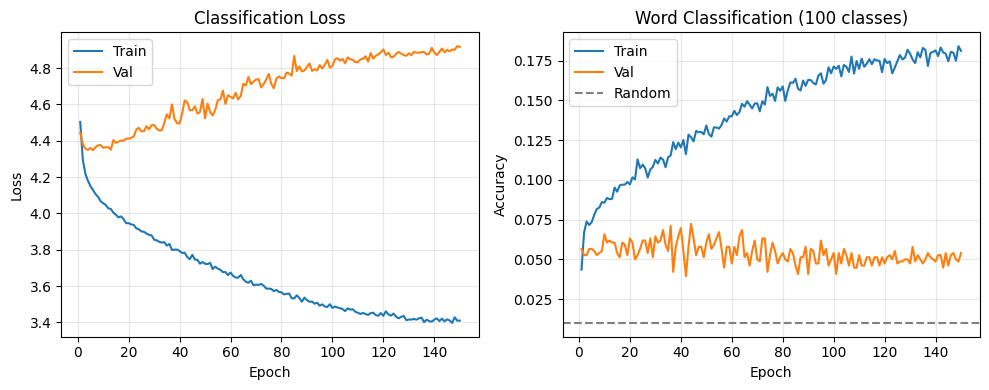

In [ ]:
# history = history_r
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Classification Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"],   label="Val")
axes[1].axhline(1/NUM_CLASSES, color="gray", linestyle="--", label="Random")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title(f"Word Classification ({NUM_CLASSES} classes)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

PLOTS_DIR = Path("pretraining_plots")
PLOTS_DIR.mkdir(exist_ok=True)
_ts    = datetime.now().strftime("%Y%m%d_%H%M%S")
_fname = (
    f"pretrain_curves"
    f"_{_ts}.png"
)
plt.savefig(PLOTS_DIR / _fname, dpi=150)
print(f"График сохранён: {PLOTS_DIR / _fname}")

plt.tight_layout()
plt.savefig("pretrain_curves.png", dpi=150)
plt.show()

## Resume: продолжить обучение с лучшей модели

Загружаем лучший чекпоинт и продолжаем обучение с меньшим LR.

In [9]:
# ── Параметры resume ──
RESUME_LR     = 5e-4
RESUME_EPOCHS = 150

# Загружаем лучшую модель из файла
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["cnn_state_dict"], strict=False)
best_val_acc = checkpoint["val_acc"]
print(f"Загружена лучшая модель (val_acc={best_val_acc:.4f})")

# Свежий optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=RESUME_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=RESUME_EPOCHS, eta_min=1e-5)

history_r = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc_r = best_val_acc
best_state_r = copy.deepcopy(model.state_dict())

for epoch in tqdm(range(1, RESUME_EPOCHS + 1), desc="Resume"):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc     = eval_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history_r["train_loss"].append(train_loss)
    history_r["val_loss"].append(val_loss)
    history_r["train_acc"].append(train_acc)
    history_r["val_acc"].append(val_acc)

    marker = ""
    if val_acc > best_val_acc_r:
        best_val_acc_r = val_acc
        best_state_r = copy.deepcopy(model.state_dict())
        marker = " *"

    if epoch % 2 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]["lr"]
        print(
            f"R-Epoch {epoch:3d} | "
            f"train_loss={train_loss:.4f}  train_acc={train_acc:.3f} | "
            f"val_loss={val_loss:.4f}  val_acc={val_acc:.3f} | "
            f"lr={lr:.2e}{marker}"
        )

# Обновляем лучшее состояние
best_state = best_state_r
best_val_acc = best_val_acc_r
print(f"Resume завершён. Best val_acc: {best_val_acc:.4f}")
print(f"Random baseline: {1/NUM_CLASSES:.4f}")


Загружена лучшая модель (val_acc=0.0658)


Resume:   0%|          | 0/150 [00:00<?, ?it/s]

R-Epoch   1 | train_loss=4.5036  train_acc=0.043 | val_loss=4.4438  val_acc=0.057 | lr=5.00e-04
R-Epoch  10 | train_loss=4.0564  train_acc=0.086 | val_loss=4.3611  val_acc=0.066 | lr=4.95e-04
R-Epoch  20 | train_loss=3.9466  train_acc=0.097 | val_loss=4.4115  val_acc=0.063 | lr=4.79e-04
R-Epoch  30 | train_loss=3.8554  train_acc=0.113 | val_loss=4.4864  val_acc=0.064 | lr=4.53e-04
R-Epoch  40 | train_loss=3.7924  train_acc=0.120 | val_loss=4.4958  val_acc=0.070 | lr=4.19e-04
R-Epoch  50 | train_loss=3.7224  train_acc=0.134 | val_loss=4.5242  val_acc=0.061 | lr=3.77e-04
R-Epoch  60 | train_loss=3.6742  train_acc=0.140 | val_loss=4.6424  val_acc=0.047 | lr=3.31e-04
R-Epoch  70 | train_loss=3.6080  train_acc=0.148 | val_loss=4.7367  val_acc=0.050 | lr=2.81e-04
R-Epoch  80 | train_loss=3.5654  train_acc=0.159 | val_loss=4.7453  val_acc=0.054 | lr=2.29e-04
R-Epoch  90 | train_loss=3.5224  train_acc=0.163 | val_loss=4.8067  val_acc=0.041 | lr=1.79e-04
R-Epoch 100 | train_loss=3.4792  train_a

## Сохранение весов CNN

In [10]:
# Загружаем лучшие веса
model.load_state_dict(best_state)

# Извлекаем только CNN часть
cnn_state = model.get_cnn_state_dict()

torch.save({
    "cnn_state_dict": cnn_state,
    "num_classes": NUM_CLASSES,
    "val_acc": best_val_acc,
    "encoder_cfg": encoder_cfg,
    "window_size": WINDOW_SIZE,
}, SAVE_PATH)

print(f"Сохранено: {SAVE_PATH}")
print(f"  val_acc (классификация): {best_val_acc:.4f}")
print(f"  Ключей в cnn_state: {len(cnn_state)}")
for k in sorted(cnn_state.keys())[:10]:
    print(f"    {k}: {cnn_state[k].shape}")

Сохранено: pretrained_cnn.pt
  val_acc (классификация): 0.0658
  Ключей в cnn_state: 62
    mbconv_blocks.0.depthwise.0.weight: torch.Size([48, 1, 3, 3])
    mbconv_blocks.0.depthwise.1.bias: torch.Size([48])
    mbconv_blocks.0.depthwise.1.num_batches_tracked: torch.Size([])
    mbconv_blocks.0.depthwise.1.running_mean: torch.Size([48])
    mbconv_blocks.0.depthwise.1.running_var: torch.Size([48])
    mbconv_blocks.0.depthwise.1.weight: torch.Size([48])
    mbconv_blocks.0.expand.0.weight: torch.Size([48, 24, 1, 1])
    mbconv_blocks.0.expand.1.bias: torch.Size([48])
    mbconv_blocks.0.expand.1.num_batches_tracked: torch.Size([])
    mbconv_blocks.0.expand.1.running_mean: torch.Size([48])


## Как загрузить в полную модель

```python
# В train_bpe.ipynb после создания модели:
model = LipReadingTransformerMBConv(MODEL_CONFIG).to(DEVICE)

# Загружаем предобученный CNN
checkpoint = torch.load("../pretrain_encoder/pretrained_cnn.pt", map_location=DEVICE)
missing, unexpected = model.encoder.load_state_dict(
    checkpoint["cnn_state_dict"], strict=False
)
print(f"Loaded pretrained CNN (val_acc={checkpoint['val_acc']:.4f})")
print(f"  Missing: {missing}")      # transformer layers — ожидаемо
print(f"  Unexpected: {unexpected}")  # должно быть пусто
```